In [1]:
import pandas as pd
import numpy as np
from joblib import load
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
in_file = "data_clean/DALYs_clean_unificado_NEW.pkl"
with open(in_file, 'rb') as f:
    df = load(f)

print(f"Dimensiones: {df.shape}")
print(f"Columnas disponibles: {df.columns.tolist()}")

Dimensiones: (242956, 26)
Columnas disponibles: ['ano', 'pais', 'codigo_pais', 'codigo_ghe', 'categoria_principal', 'categoria_nivel1', 'categoria_nivel2', 'causa', 'sexo', 'edad', 'dalys', 'pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 'humedad_relativa', 'poblacion_abs', 'tasa_dalys_100k', 'dalys_por_intervencion', 'desarrollo_vs_carga']


In [4]:
#================================================================
# ¿Cómo ha evolucionado la carga de NTDs (DALYs) a nivel regional?
#================================================================

vars_contextuales = ['pib_per_capita', 'idh', 'indice_educacion', 'indice_salud',
                     'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 'co2_anual',
                     'precipitacion_total', 'temperatura_superficial', 'humedad_relativa',
                     'dalys_por_intervencion',
                     'desarrollo_vs_carga']

# Agrupamos por 'ano' y 'pais' (y añadimos 'codigo_pais' para facilitar mapas)
df_pais_anual = df.groupby(['ano', 'pais', 'codigo_pais']).agg({
    'dalys': 'sum',
    'poblacion_abs': 'first'    # La población es constante por país y año
}).reset_index()

# Recalculamos la tasa correctamente (evita usar 'first' que puede traer valores incorrectos)
df_pais_anual['tasa_dalys_100k'] = (df_pais_anual['dalys'] / df_pais_anual['poblacion_abs']) * 100000

# CORRECCIÓN: Eliminar sexo y edad ANTES de crear df_contexto_pais
# Creamos un subconjunto sin las columnas que causan duplicados
columnas_sin_demografia = ['ano', 'pais', 'codigo_pais'] + vars_contextuales
df_contexto_pais = df[columnas_sin_demografia].drop_duplicates()

# Verificamos que no haya duplicados
print(f"Filas en df_contexto_pais: {len(df_contexto_pais)}")
print(f"Combinaciones únicas año-país: {df[['ano', 'pais']].drop_duplicates().shape[0]}")

# Unimos
df_pais_anual = pd.merge(df_pais_anual, df_contexto_pais, on=['ano', 'pais', 'codigo_pais'], how='inner')

# Eliminamos cualquier duplicado que pueda quedar
df_pais_anual = df_pais_anual.drop_duplicates(subset=['ano', 'codigo_pais'])

print("\n     Descripción: DALYs totales por país y año, con variables contextuales específicas de cada país.")
print(f"     Dimensiones: {df_pais_anual.shape}")
print(f"     Número de países: {df_pais_anual['pais'].nunique()}")
print(f"     Años: {df_pais_anual['ano'].nunique()}")
display(df_pais_anual.head())

Filas en df_contexto_pais: 138042
Combinaciones únicas año-país: 869

     Descripción: DALYs totales por país y año, con variables contextuales específicas de cada país.
     Dimensiones: (869, 19)
     Número de países: 155
     Años: 6


,ano,pais,codigo_pais,dalys,poblacion_abs,tasa_dalys_100k,pib_per_capita,idh,indice_educacion,indice_salud,indice_ingresos,esperanza_vida,poblacion_miles,co2_anual,precipitacion_total,temperatura_superficial,humedad_relativa,dalys_por_intervencion,desarrollo_vs_carga
0,2000,Afghanistan,AFG,367.709300,2152578.0,17.082275,1617.8264,NaN,0.283,0.558,NaN,53.76,2152.578,511.1,0.009,9.687,40.39,0.000017,NaN
190,2000,Albania,ALB,2.260270,144500.0,1.564201,6262.7900,0.701,0.614,0.848,0.662,72.65,144.500,13719.0,0.032,12.860,68.98,0.000008,0.066209
272,2000,Algeria,DZA,45.856595,1569232.0,2.922232,11558.2210,0.697,0.563,0.793,0.757,69.07,1569.232,18827.0,0.007,18.430,46.25,0.000002,0.071921
448,2000,Armenia,ARM,1.421628,105202.0,1.351331,4589.0083,0.669,0.641,0.760,0.614,66.89,105.202,30107.0,0.020,7.193,61.04,0.000010,0.060751
600,2000,Australia,AUS,0.623858,658510.0,0.094738,45099.0740,0.909,0.883,0.915,0.930,76.95,658.510,11832.0,0.026,18.700,61.30,0.000002,0.000274


## Descripción de Datos

In [5]:
# Exploración rápida
df_pais_anual.describe().round(4)

,ano,dalys,poblacion_abs,tasa_dalys_100k,pib_per_capita,idh,indice_educacion,indice_salud,indice_ingresos,esperanza_vida,poblacion_miles,co2_anual,precipitacion_total,temperatura_superficial,humedad_relativa,dalys_por_intervencion,desarrollo_vs_carga
count,869.0000,869.0000,8.690000e+02,869.0000,833.0000,802.0000,857.0000,850.0000,831.0000,850.0000,869.0000,8.630000e+02,863.0000,863.0000,863.0000,869.0000,802.0000
mean,2014.6145,761.7282,2.106805e+06,33.5589,23208.9772,0.7259,0.6525,0.7825,0.7486,68.3617,2106.8048,1.335889e+05,0.0390,18.9905,66.9160,0.0001,2.3258
std,7.1032,3167.5036,6.812985e+06,77.0243,24700.2900,0.1478,0.1697,0.1283,0.1757,8.3390,6812.9845,5.429849e+05,0.0284,7.8551,14.7705,0.0002,6.5678
min,2000.0000,0.0001,2.651000e+03,0.0007,711.9764,0.3080,0.1510,0.3890,0.2870,42.7800,2.6510,1.713000e+02,0.0000,-0.1970,24.6100,0.0000,0.0000
25%,2010.0000,0.6539,1.392600e+05,0.3751,5178.4473,0.6132,0.5370,0.6902,0.6160,62.3600,139.2600,1.060800e+04,0.0210,11.8400,59.2150,0.0000,0.0022
50%,2019.0000,11.1298,4.374460e+05,3.5950,14427.6010,0.7445,0.6630,0.7960,0.7670,69.2150,437.4460,3.018400e+04,0.0320,21.9000,70.7700,0.0000,0.0196
75%,2020.0000,274.7548,1.567997e+06,16.8365,34369.8800,0.8362,0.7840,0.8800,0.9010,74.6975,1567.9970,7.513000e+04,0.0510,25.8650,77.8450,0.0000,0.2563
max,2021.0000,42288.6187,6.901619e+07,631.4035,136772.4400,0.9750,0.9660,0.9920,1.0000,82.0000,69016.1940,6.550021e+06,0.1650,29.6100,87.5100,0.0013,54.2460


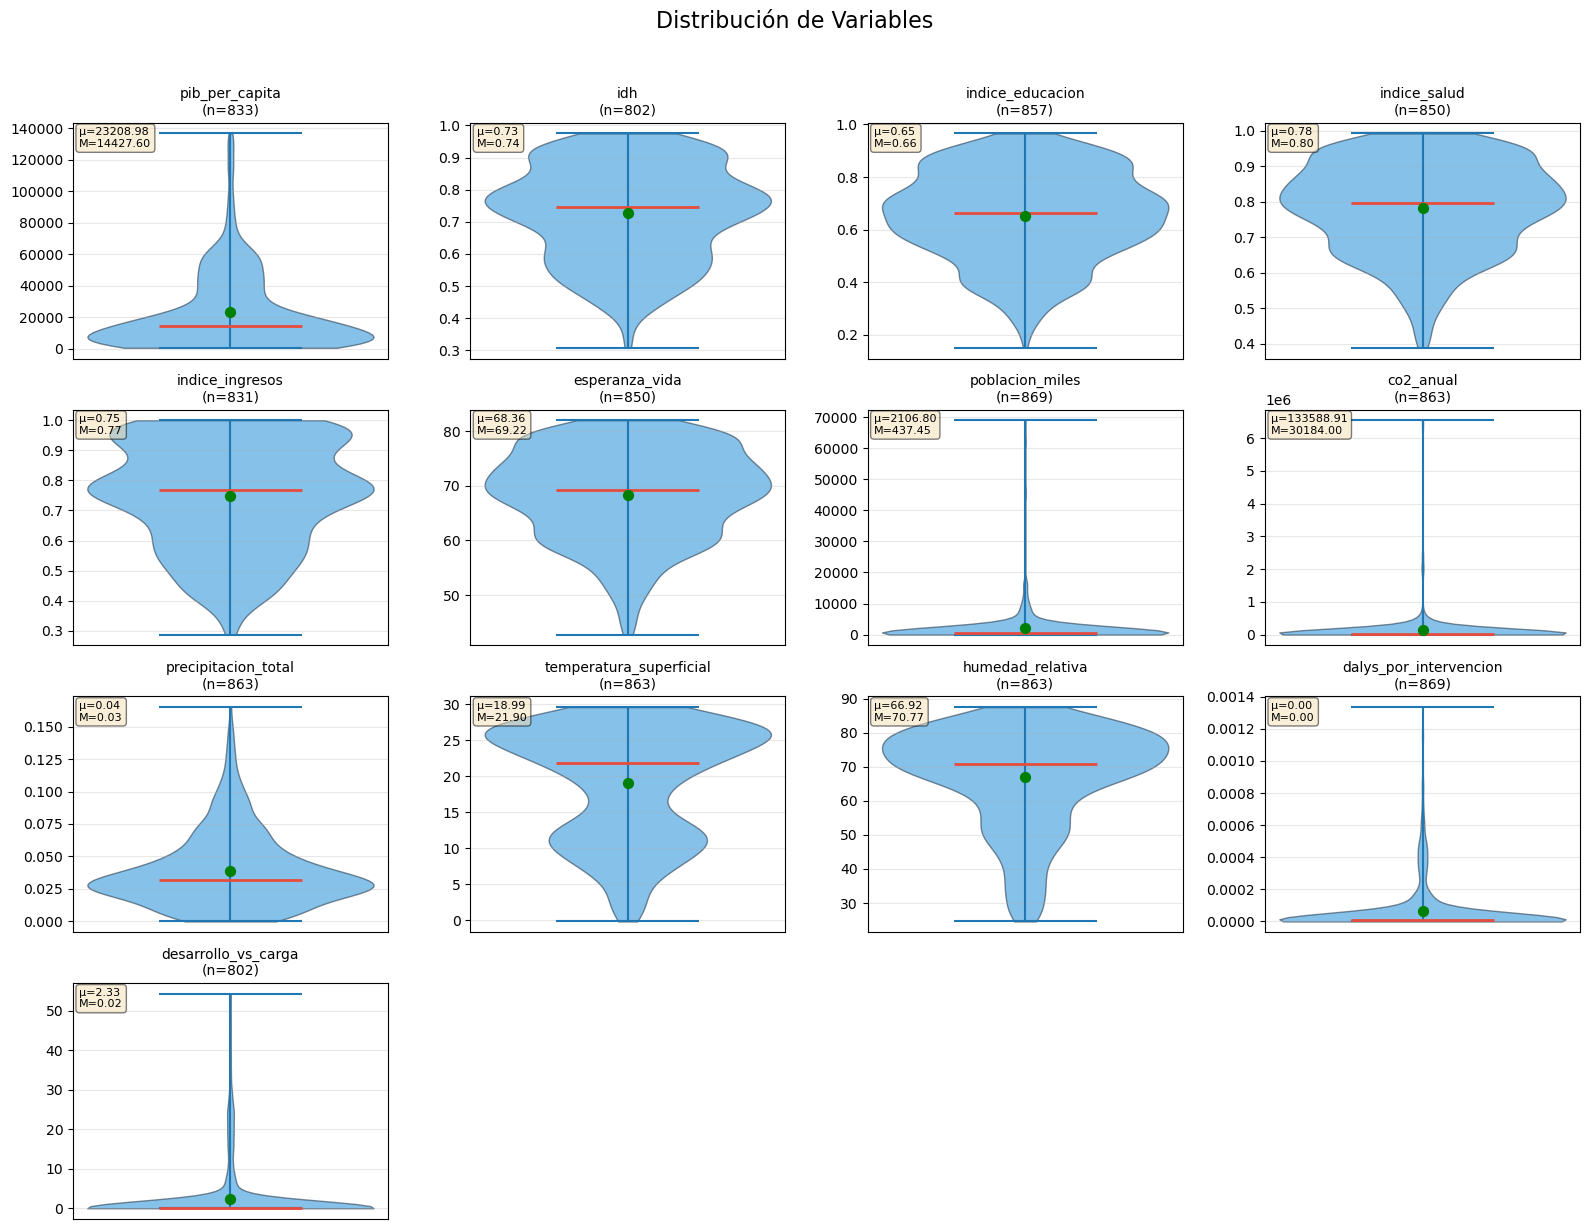

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def violin_plot_all_in_one(df, cols=None, figsize=(20, 12)):
    """
    Muestra TODOS los violin plots
    """
    if cols is None:
        cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # Calcular grid óptimo
    n_vars = len(cols)
    n_cols = min(4, n_vars)  # Máximo 4 columnas
    n_rows = int(np.ceil(n_vars / n_cols))
    
    # Crear figura única
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.suptitle('Distribución de Variables', fontsize=16, y=1.02)
    
    # Aplanar axs para fácil iteración
    axs = axs.flatten() if n_rows > 1 else [axs] if n_cols == 1 else axs
    
    # Crear violin plot para cada variable
    for i, col in enumerate(cols):
        # Datos limpios
        data_clean = df[col].dropna()
        
        # Violin plot
        parts = axs[i].violinplot(data_clean, 
                                 positions=[0],
                                 showmeans=False,
                                 showmedians=True,
                                 widths=0.8)
        
        # Estilizar
        for pc in parts['bodies']:
            pc.set_facecolor('#3498db')
            pc.set_alpha(0.6)
            pc.set_edgecolor('#2c3e50')
        
        if 'cmedians' in parts:
            parts['cmedians'].set_color('#e74c3c')
            parts['cmedians'].set_linewidth(2)
        
        # Añadir estadísticas básicas
        mean_val = data_clean.mean()
        median_val = data_clean.median()
        axs[i].scatter(0, mean_val, color='green', s=50, zorder=3, label='Media')
        
        axs[i].set_title(f'{col}\n(n={len(data_clean):,})', fontsize=10)
        axs[i].set_xticks([])
        axs[i].grid(axis='y', alpha=0.3)
        
        # Añadir texto con estadísticas
        stats_text = f'μ={mean_val:.2f}\nM={median_val:.2f}'
        axs[i].text(0.02, 0.98, stats_text, 
                   transform=axs[i].transAxes,
                   verticalalignment='top',
                   fontsize=8,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Eliminar subplots vacíos
    for i in range(len(cols), len(axs)):
        fig.delaxes(axs[i])
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Uso
fig = violin_plot_all_in_one(df_pais_anual, vars_contextuales, figsize=(16, 12))

In [7]:
vars_salud = ['dalys', 'tasa_dalys_100k']

# Crear lista completa para correlación
vars_para_correlacion = vars_contextuales + vars_salud

# Obtneción de correlaciones
df_corr = df_pais_anual[vars_para_correlacion].corr()

df_corr

,pib_per_capita,idh,indice_educacion,indice_salud,indice_ingresos,esperanza_vida,poblacion_miles,co2_anual,precipitacion_total,temperatura_superficial,humedad_relativa,dalys_por_intervencion,desarrollo_vs_carga,dalys,tasa_dalys_100k
pib_per_capita,1.000000,0.774374,0.666148,0.707517,0.810114,0.707470,-0.138843,0.404306,-0.167893,-0.365848,0.140647,-0.265922,-0.289206,-0.172551,-0.331349
idh,0.774374,1.000000,0.935302,0.905420,0.951750,0.905398,-0.121302,0.218308,-0.102112,-0.515211,0.294575,-0.523365,-0.548811,-0.283303,-0.622343
indice_educacion,0.666148,0.935302,1.000000,0.764615,0.817461,0.764563,-0.118620,0.147696,-0.087627,-0.616517,0.352094,-0.478443,-0.477048,-0.245240,-0.558445
indice_salud,0.707517,0.905420,0.764615,1.000000,0.849125,0.999997,-0.061554,0.233523,-0.027347,-0.394076,0.286947,-0.520978,-0.541431,-0.320853,-0.613973
indice_ingresos,0.810114,0.951750,0.817461,0.849125,1.000000,0.849121,-0.101681,0.242489,-0.154806,-0.417664,0.169596,-0.496893,-0.530393,-0.252585,-0.597913
esperanza_vida,0.707470,0.905398,0.764563,0.999997,0.849121,1.000000,-0.061417,0.233507,-0.027317,-0.394040,0.286944,-0.521003,-0.541473,-0.320810,-0.613969
poblacion_miles,-0.138843,-0.121302,-0.118620,-0.061554,-0.101681,-0.061417,1.000000,-0.002339,0.052555,0.043454,-0.036795,-0.017532,0.027867,0.408706,0.010437
co2_anual,0.404306,0.218308,0.147696,0.233523,0.242489,0.233507,-0.002339,1.000000,0.027663,0.106394,0.039112,-0.078667,-0.079099,-0.038740,-0.085133
precipitacion_total,-0.167893,-0.102112,-0.087627,-0.027347,-0.154806,-0.027317,0.052555,0.027663,1.000000,0.170316,0.672488,0.086953,0.071158,0.027269,0.112602
temperatura_superficial,-0.365848,-0.515211,-0.616517,-0.394076,-0.417664,-0.394040,0.043454,0.106394,0.170316,1.000000,-0.197315,0.326856,0.323221,0.186694,0.360729


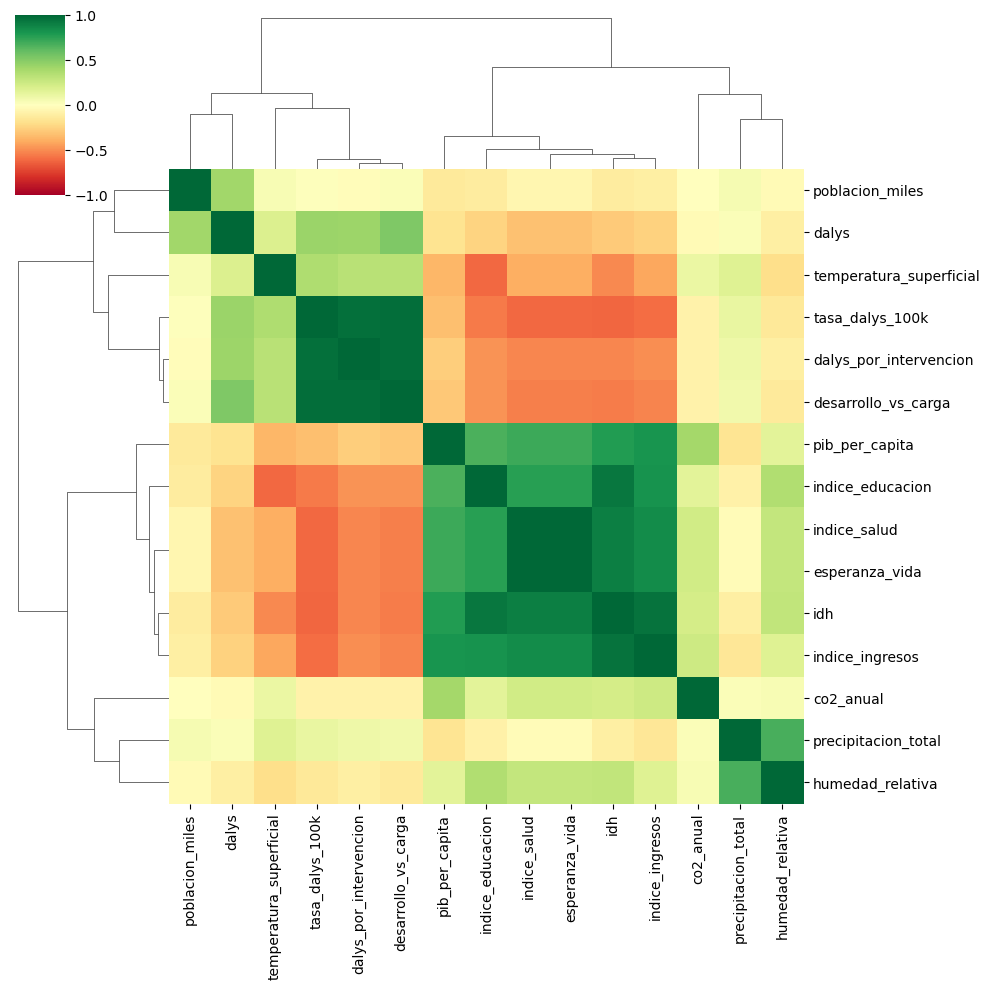

In [8]:
# CLUSTERMAP
sns.clustermap(df_corr, cmap='RdYlGn', vmin=-1, vmax=1)

In [9]:
# Ejemplo con dos variables: DALYs y PIB per cápita

from scipy.stats import pearsonr

df_clean = df_pais_anual[['dalys'] + vars_contextuales].dropna()

corr, p = pearsonr(df_clean['dalys'], df_clean['pib_per_capita'])
corr, p

(np.float64(-0.1703978184640959), np.float64(1.8619116913863695e-06))

In [10]:
from itertools import combinations
from scipy.stats import pearsonr

# Seleccionar solo numéricas
vars_salud = ['dalys', 'tasa_dalys_100k']
vars_para_correlacion = vars_contextuales + vars_salud

# Verificar que todas las variables existen y son numéricas
cols_numericas = [col for col in vars_para_correlacion 
                  if col in df_pais_anual.columns 
                  and df_pais_anual[col].dtype in ['float64', 'int64']]

print(f"Variables numéricas para correlación ({len(cols_numericas)}):")
print(cols_numericas)

# Iteración sobre todas las combinaciones de variables numéricas
df_corr_list = []
for var1, var2 in combinations(cols_numericas, 2):
    # Eliminar NaN para el par específico
    data = df_pais_anual[[var1, var2]].dropna()
    
    if len(data) > 2:  # Mínimo 3 puntos para correlación
        corr, p_valor = pearsonr(data[var1], data[var2])
        df_corr_list.append([var1, var2, len(data), corr, p_valor])

# Crear DataFrame con resultados
df_corr = pd.DataFrame(df_corr_list)
df_corr.columns = ['var1', 'var2', 'N', 'pearson', 'p_pearson']
df_corr = df_corr.dropna().sort_values('pearson', key=abs, ascending=False)

# Mostrar resultados
print(f"\nTotal de correlaciones calculadas: {len(df_corr)}")
display(df_corr.head(10))

Variables numéricas para correlación (15):
['pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 'humedad_relativa', 'dalys_por_intervencion', 'desarrollo_vs_carga', 'dalys', 'tasa_dalys_100k']

Total de correlaciones calculadas: 105


,var1,var2,N,pearson,p_pearson
40,indice_salud,esperanza_vida,850,0.999997,0.000000e+00
103,desarrollo_vs_carga,tasa_dalys_100k,802,0.976478,0.000000e+00
99,dalys_por_intervencion,desarrollo_vs_carga,802,0.969189,0.000000e+00
101,dalys_por_intervencion,tasa_dalys_100k,869,0.961498,0.000000e+00
16,idh,indice_ingresos,802,0.951750,0.000000e+00
14,idh,indice_educacion,802,0.935302,0.000000e+00
15,idh,indice_salud,802,0.905420,6.446512e-300
17,idh,esperanza_vida,802,0.905398,7.046703e-300
39,indice_salud,indice_ingresos,812,0.849125,9.539761e-227
50,indice_ingresos,esperanza_vida,812,0.849121,9.635322e-227


In [11]:
# ¿Cuántas no son significativas?
(df_corr['p_pearson']>0.05).sum()

np.int64(15)

In [12]:
# Me quedo con aquellas con valor p menor a 0.05
df_corr = df_corr[df_corr['p_pearson']<=0.05]

<Axes: ylabel='Frequency'>

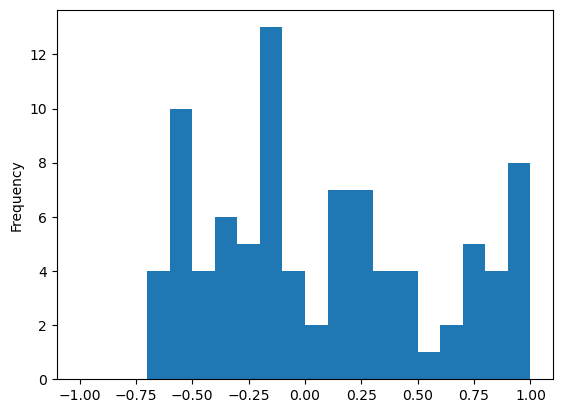

In [13]:
df_corr['pearson'].plot.hist(bins=[i/10 for i in range(-10,11,1)])

<Axes: xlabel='var2', ylabel='var1'>

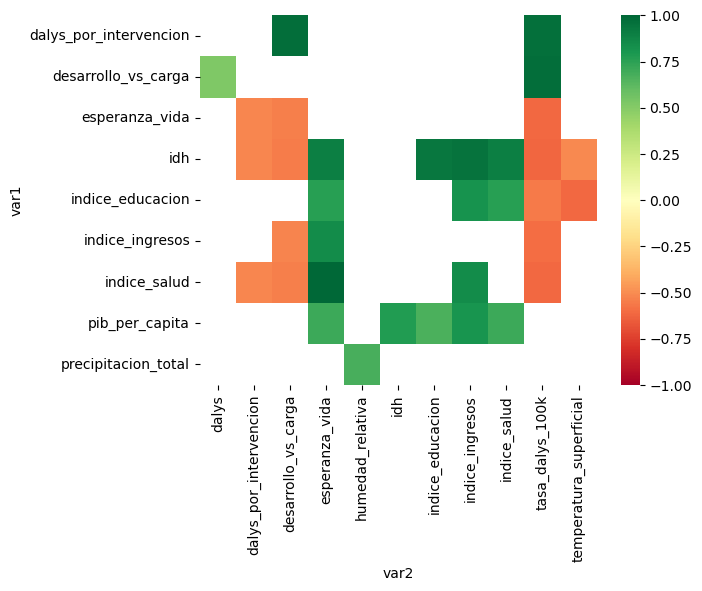

In [14]:
corr_thr = 0.50
data = df_corr[df_corr['pearson'].abs()>=corr_thr]
data = data.pivot(index='var1', columns='var2', values='pearson')
sns.heatmap( data, cmap='RdYlGn', vmin=-1, vmax=1)

In [15]:
# Pruebas Estadísticas ajustadas al número de variables probadas

from statsmodels.stats.multitest import multipletests

rejected, pvals_corrected, _, _ = multipletests(df_corr['p_pearson'], alpha=0.05, method='bonferroni')

# Resultados
print("Hipótesis rechazadas:", rejected.sum())

Hipótesis rechazadas: 77


In [16]:
df_corr['rejected'] = rejected
df_corr['p_corrected'] = pvals_corrected

df_corr[~df_corr['rejected']]

,var1,var2,N,pearson,p_pearson,rejected,p_corrected
18,idh,poblacion_miles,802,-0.121302,0.000576,False,0.051854
89,precipitacion_total,tasa_dalys_100k,863,0.112602,0.000921,False,0.082879
97,humedad_relativa,dalys,863,-0.108935,0.001350,False,0.121528
95,humedad_relativa,dalys_por_intervencion,863,-0.106631,0.001708,False,0.153680
78,co2_anual,temperatura_superficial,863,0.106394,0.001749,False,0.157391
20,idh,precipitacion_total,796,-0.102112,0.003927,False,0.353441
51,indice_ingresos,poblacion_miles,831,-0.101681,0.003342,False,0.300809
32,indice_educacion,precipitacion_total,851,-0.087627,0.010546,False,0.949119
86,precipitacion_total,dalys_por_intervencion,863,0.086953,0.010603,False,0.954228
83,co2_anual,tasa_dalys_100k,863,-0.085133,0.012355,False,1.000000


In [17]:
df_pais_anual.to_csv('df_pais_anual.csv', index=False)

In [ ]:
# Modificación de la escala de datos 

from sklearn.preprocessing import StandardScaler
import pandas as pd

df_pais_anual = pd.read_csv('df_pais_anual.csv')

# Crear una copia del DataFrame para no modificar el original
df_scaled = df_pais_anual.copy()

# Seleccionar solo columnas numéricas (excluyendo identificadores)
columnas_numericas = df_pais_anual.select_dtypes(include=['float64', 'int64']).columns.tolist()
columnas_excluir = ['ano', 'codigo_pais']  # Columnas que no queremos escalar
columnas_a_escalar = [col for col in columnas_numericas if col not in columnas_excluir]

print(f"Columnas a estandarizar ({len(columnas_a_escalar)}):")
print(columnas_a_escalar)

# Aplicar StandardScaler
scaler = StandardScaler()
df_scaled[columnas_a_escalar] = scaler.fit_transform(df_pais_anual[columnas_a_escalar])

# Verificar resultados
display(df_scaled[columnas_a_escalar].describe().round(3))

display(df_scaled.head())



Columnas a estandarizar (16):
['dalys', 'poblacion_abs', 'tasa_dalys_100k', 'pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 'humedad_relativa', 'dalys_por_intervencion', 'desarrollo_vs_carga']

✅ Datos estandarizados (media ≈ 0, desviación ≈ 1):


,dalys,poblacion_abs,tasa_dalys_100k,pib_per_capita,idh,indice_educacion,indice_salud,indice_ingresos,esperanza_vida,poblacion_miles,co2_anual,precipitacion_total,temperatura_superficial,humedad_relativa,dalys_por_intervencion,desarrollo_vs_carga
count,869.000,869.000,869.000,833.000,802.000,857.000,850.000,831.000,850.000,869.000,863.000,863.000,863.000,863.000,869.000,802.000
mean,-0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-0.241,-0.309,-0.436,-0.911,-2.829,-2.957,-3.069,-2.629,-3.070,-0.309,-0.246,-1.374,-2.444,-2.866,-0.419,-0.354
25%,-0.240,-0.289,-0.431,-0.730,-0.763,-0.681,-0.719,-0.755,-0.720,-0.289,-0.227,-0.634,-0.911,-0.522,-0.404,-0.354
50%,-0.237,-0.245,-0.389,-0.356,0.126,0.062,0.106,0.105,0.102,-0.245,-0.191,-0.247,0.371,0.261,-0.377,-0.351
75%,-0.154,-0.079,-0.217,0.452,0.747,0.775,0.761,0.868,0.760,-0.079,-0.108,0.422,0.876,0.740,-0.180,-0.315
max,13.118,9.827,7.766,4.600,1.686,1.848,1.634,1.432,1.636,9.827,11.824,4.435,1.353,1.395,7.857,7.910



📊 Primeras filas de datos estandarizados:


,ano,pais,codigo_pais,dalys,poblacion_abs,tasa_dalys_100k,pib_per_capita,idh,indice_educacion,indice_salud,indice_ingresos,esperanza_vida,poblacion_miles,co2_anual,precipitacion_total,temperatura_superficial,humedad_relativa,dalys_por_intervencion,desarrollo_vs_carga
0,2000,Afghanistan,AFG,-0.124466,0.006722,-0.214038,-0.874651,NaN,-2.178492,-1.750970,NaN,-1.752035,0.006722,-0.245228,-1.056920,-1.185081,-1.796915,-0.310934,NaN
1,2000,Albania,ALB,-0.239907,-0.288190,-0.415624,-0.686485,-0.168707,-0.227102,0.511194,-0.493066,0.514553,-0.288190,-0.220889,-0.247146,-0.780903,0.139817,-0.370462,-0.344249
2,2000,Algeria,DZA,-0.226135,-0.078950,-0.397982,-0.471968,-0.195788,-0.527769,0.082163,0.048102,0.084993,-0.078950,-0.211476,-1.127335,-0.071396,-1.399949,-0.408867,-0.343379
3,2000,Armenia,ARM,-0.240172,-0.293962,-0.418389,-0.754289,-0.385355,-0.067925,-0.175256,-0.766499,-0.176583,-0.293962,-0.190690,-0.669637,-1.502767,-0.398051,-0.354663,-0.345081
4,2000,Australia,AUS,-0.240424,-0.212701,-0.434713,0.886761,1.239503,1.358771,1.033832,1.033597,1.030504,-0.212701,-0.224366,-0.458392,-0.037003,-0.380439,-0.409781,-0.354294


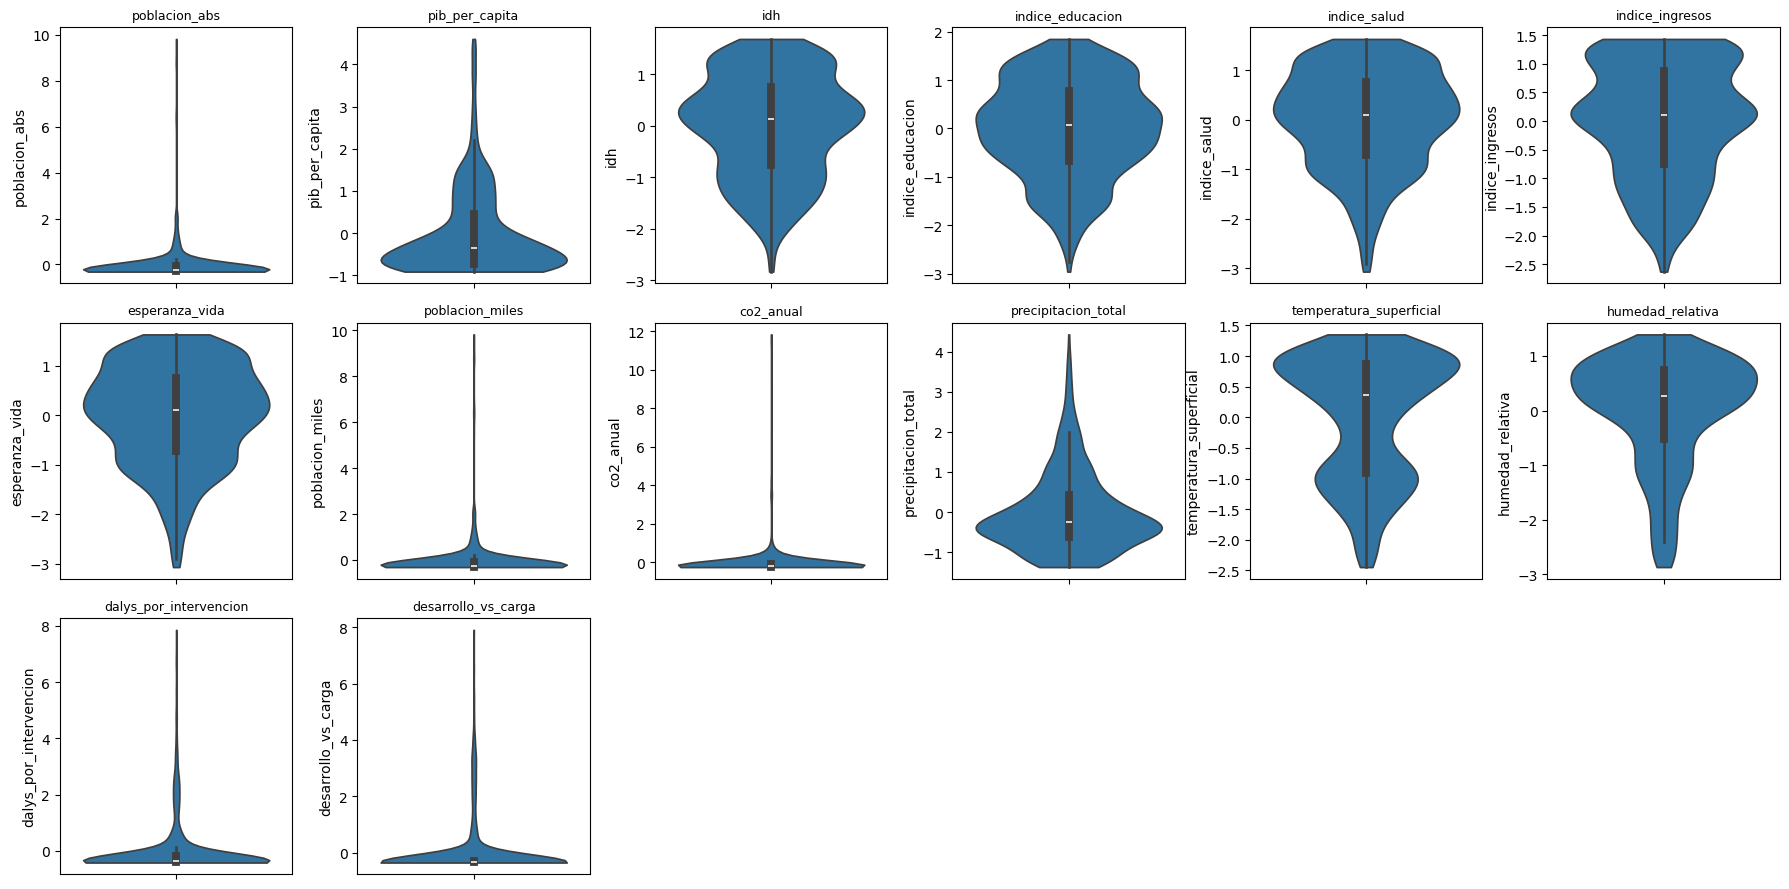

In [44]:
from math import ceil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def violin_plot_dalys_ajustado(df_scaled, cols=None, n_row=8):
    # Seleccionar solo columnas numéricas
    if cols is None:
        cols = df_scaled.select_dtypes(include=['float64', 'int64']).columns.tolist()
        excluir = ['tasa_dalys_100k', 'dalys', 'ano', 'codigo_pais']
        cols = [col for col in cols if col not in excluir]
    
    # Crear figura con todos los subplots
    n_cols = n_row
    n_rows = ceil(len(cols) / n_cols)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    axs = axs.flatten()
    
    for i, col in enumerate(cols):
        sns.violinplot(data=df_scaled, y=col, cut=0, ax=axs[i])
        axs[i].set_title(col, fontsize=9)
    
    # Ocultar subplots vacíos
    for i in range(len(cols), len(axs)):
        axs[i].axis('off')
    
    plt.tight_layout()
    plt.show()

violin_plot_dalys_ajustado(df_scaled, n_row=6)

In [ ]:
# Plots para las variables ajustadas
from sklearn.decomposition import PCA

# Excluir columnas no numéricas y 'diagnostic' si existe
columnas_numericas = df_scaled.select_dtypes(include=['float64', 'int64']).columns.tolist()
columnas_excluir = ['ano', 'dalys']
columnas_pca = [col for col in columnas_numericas if col not in columnas_excluir]

# Imputar valores con media
df_pca = df_scaled[columnas_pca].fillna(df_scaled[columnas_pca].mean())  # Imlputación con media

n_components = 5
pca = PCA(n_components=n_components)
pca.fit(df_pca)

df_components = pca.components_
df_components = pd.DataFrame(df_components, 
                             columns=columnas_pca,
                             index=['comp_{}'.format(i) for i in range(n_components)])

df_components.insert(0, 'explained_variance_percent', pca.explained_variance_ratio_ * 100)
df_components

,explained_variance_percent,poblacion_abs,tasa_dalys_100k,pib_per_capita,idh,indice_educacion,indice_salud,indice_ingresos,esperanza_vida,poblacion_miles,co2_anual,precipitacion_total,temperatura_superficial,humedad_relativa,dalys_por_intervencion,desarrollo_vs_carga
comp_0,43.778758,0.049201,0.302145,-0.288454,-0.350661,-0.341906,-0.353055,-0.339519,-0.353048,0.049201,-0.096900,0.039450,0.216399,-0.116546,0.273674,0.264536
comp_1,13.983002,0.658524,-0.184560,-0.130067,-0.056742,-0.046458,0.008029,-0.053554,0.008126,0.658524,-0.034665,0.054030,-0.004018,0.002447,-0.212706,-0.154758
comp_2,11.678189,0.078269,0.215582,0.061649,0.069497,0.080119,0.094786,0.012258,0.094796,0.078269,0.128381,0.641317,0.054159,0.620206,0.236032,0.192442
comp_3,10.421797,0.226500,0.353479,0.359652,0.150179,0.065969,0.100993,0.210014,0.100996,0.226500,0.325663,-0.310923,0.029076,-0.279621,0.393619,0.339099
comp_4,7.661124,-0.066613,-0.160904,0.068678,-0.093416,-0.232218,0.035080,-0.022957,0.035097,-0.066613,0.674020,0.129050,0.588281,-0.100589,-0.193378,-0.174166


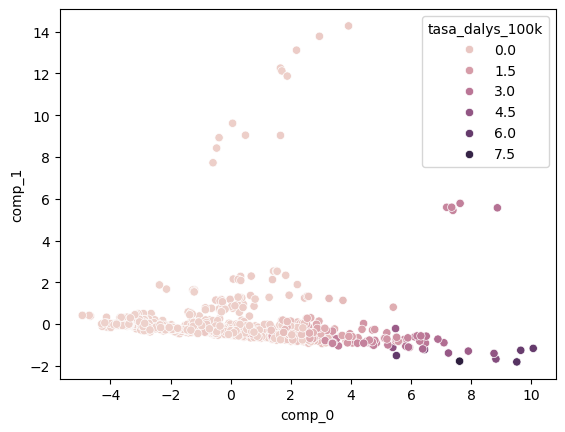

In [49]:
from sklearn.decomposition import PCA

columnas_numericas = df_scaled.select_dtypes(include=['float64', 'int64']).columns.tolist()
columnas_excluir = ['ano', 'codigo_pais']
columnas_pca = [col for col in columnas_numericas if col not in columnas_excluir]

# Imputar NaN
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df_pca_imputed = imputer.fit_transform(df_scaled[columnas_pca])

# Entrenar nuevo PCA
n_components = 5
pca = PCA(n_components=n_components)
pca.fit(df_pca_imputed)

# Transformar datos
df_data_pca = pca.transform(df_pca_imputed)
df_data_pca = pd.DataFrame(df_data_pca, columns=[f'comp_{i}' for i in range(n_components)])
df_data_pca['tasa_dalys_100k'] = df_scaled['tasa_dalys_100k'].values
df_data_pca

# Graficar
sns.scatterplot(data=df_data_pca, x='comp_0', y='comp_1', hue='tasa_dalys_100k')
plt.show()

In [38]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
import pandas as pd

# Preparar datos
X = df_pais_anual.drop('dalys', axis=1)
y = df_pais_anual['dalys']

# Seleccionar solo columnas numéricas
X_numeric = X.select_dtypes(include=['float64', 'int64'])

# Imputar NaN con la media
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_numeric)

# Convertir a DataFrame manteniendo nombres de columnas
X_imputed = pd.DataFrame(X_imputed, columns=X_numeric.columns)

# Aplicar SelectKBest con f_classif (ANOVA)
feature_selection = SelectKBest(f_classif, k=5)
feature_selection.fit(X_imputed, y)

# Obtener nombres de características seleccionadas
selected_features = X_numeric.columns[feature_selection.get_support()].tolist()
print("Características seleccionadas:")
print(selected_features)

# Ver puntuaciones
scores = pd.DataFrame({
    'feature': X_numeric.columns,
    'score': feature_selection.scores_
}).sort_values('score', ascending=False)
print("\nPuntuaciones de todas las características:")
print(scores)

Características seleccionadas:
['precipitacion_total', 'temperatura_superficial', 'humedad_relativa', 'dalys_por_intervencion', 'desarrollo_vs_carga']

Puntuaciones de todas las características:
                    feature  score
0                       ano    NaN
1             poblacion_abs    NaN
2           tasa_dalys_100k    NaN
3            pib_per_capita    NaN
4                       idh    NaN
5          indice_educacion    NaN
6              indice_salud    NaN
7           indice_ingresos    NaN
8            esperanza_vida    NaN
9           poblacion_miles    NaN
10                co2_anual    NaN
11      precipitacion_total    NaN
12  temperatura_superficial    NaN
13         humedad_relativa    NaN
14   dalys_por_intervencion    NaN
15      desarrollo_vs_carga    NaN


c:\Users\troop\anaconda3\envs\skearn\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


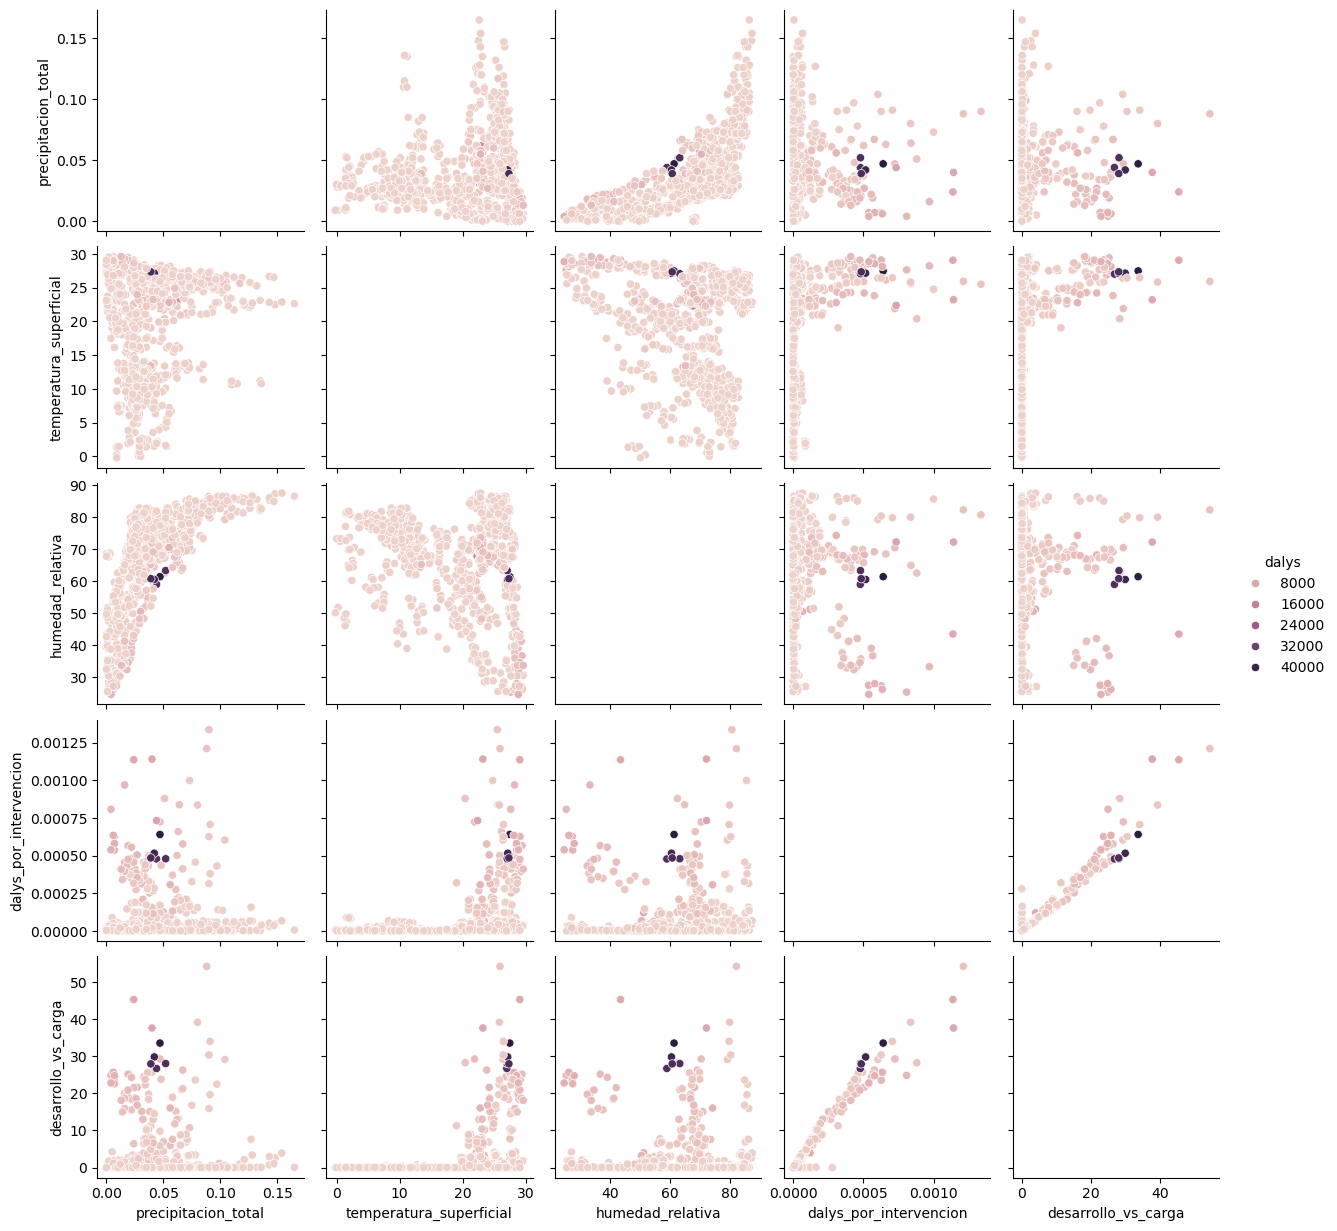

In [39]:
df_selected = df_pais_anual[ selected_features + ['dalys'] ]
sns.pairplot(df_selected, hue='dalys')

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dalys.data, cancer.target, test_size=0.3, random_state=42)
X_train, y_train